# Week 3 - Batch 3 Anomaly Detection

This notebook implements a two-stage strategy for `third_batch.npz`:
1. Supervised ensemble for the 4 known anomaly types
2. Unsupervised ensemble as insurance for the unknown 5th anomaly type

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler

from feature_pipeline import (
    combine_labeled_data, load_data, load_npz,
    compute_item_stats, build_features,
    generate_synthetic_anomalies, add_unsupervised_score_features,
    get_feature_columns
)

np.random.seed(42)

In [2]:
# Step 1: Combine ALL labeled data, then load third batch test
combined_path = combine_labeled_data(
    'data/training_batch_with_labels.npz',
    'data/first_batch_with_labels.npz',
    'data/second_batch_with_labels.npz',
    output_path='data/combined_all_labeled.npz'
)

XX_train, yy, XX_test = load_data(combined_path, test_path='data/third_batch.npz')
print('Train interactions:', XX_train.shape)
print('Train users:', yy.shape)
print('Test interactions:', XX_test.shape)
print('Anomaly rate:', yy['label'].mean())

Combined 3 files → data/combined_all_labeled.npz
  3060 users (260 anomalous, 2800 normal), 479433 interactions
Train interactions: (479433, 3)
Train users: (3060, 2)
Test interactions: (256072, 3)
Anomaly rate: 0.08496732026143791


In [3]:
# Optional: broaden supervised signal with synthetic anomalies
USE_SYNTH = True
if USE_SYNTH:
    XX_train_aug, yy_aug = generate_synthetic_anomalies(XX_train, yy, n_per_type=20, seed=42)
else:
    XX_train_aug, yy_aug = XX_train.copy(), yy.copy()

print('Augmented interactions:', XX_train_aug.shape)
print('Augmented users:', yy_aug.shape)
print('Augmented anomaly rate:', yy_aug['label'].mean())

Generated 260 synthetic anomalous users (13 types x 20)
  Training: 3060 -> 3320 users (260 + 260 = 520 anomalous)
Augmented interactions: (524073, 3)
Augmented users: (3320, 2)
Augmented anomaly rate: 0.1566265060240964


In [4]:
# Step 2 + 3: Feature engineering with temporal, graph, and robust profile features
item_stats = compute_item_stats(XX_train_aug, yy_train=yy_aug)
train_feats = build_features(XX_train_aug, item_stats)
test_feats = build_features(XX_test, item_stats)

print('Train feature table:', train_feats.shape)
print('Test feature table:', test_feats.shape)
train_feats.head(2)

Train feature table: (3320, 61)
Test feature table: (1625, 61)


,user,rating_mean,rating_std,rating_median,rating_min,rating_max,rating_count,rating_range,first_half_rating_mean,second_half_rating_mean,...,std_item_avg_rating,js_divergence,item_selection_gini,prop_rare_items,prop_common_items,avg_neighbor_similarity,jaccard_to_nearest_normal,mf_rmse,mf_mae,cosine_sim_to_avg
0,100,3.147727,1.169928,3.0,0,5,88,5,3.431818,2.863636,...,0.317451,0.097006,0.0,0.0,0.920455,0.477535,0.306569,0.842137,0.637633,0.107989
1,101,3.406926,0.854016,3.0,0,5,231,5,3.478261,3.336207,...,0.384343,0.167730,0.0,0.0,0.922078,0.648172,0.478049,0.682867,0.481329,0.385247


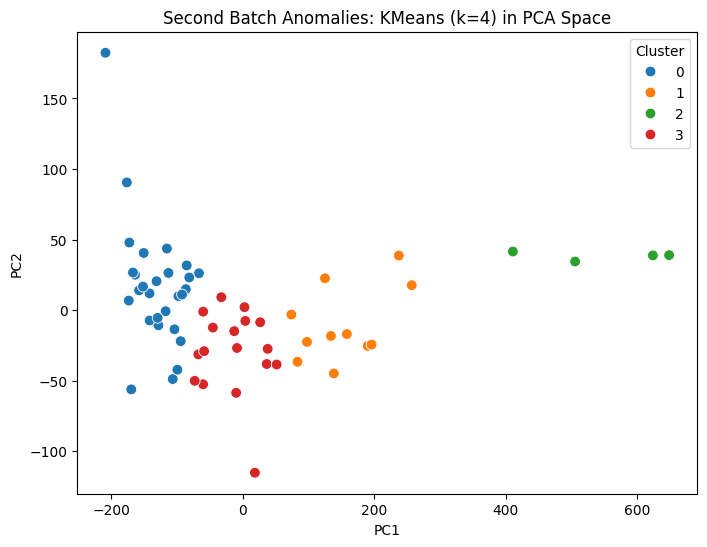

cluster,0,1,2,3
rating_mean,3.489744,3.622263,4.071311,3.484921
rating_std,0.888207,0.880599,0.553102,0.838755
rating_median,3.642857,3.636364,4.000000,3.470588
rating_min,1.785714,1.636364,2.500000,1.705882
rating_max,4.678571,4.818182,5.000000,4.764706
rating_count,48.428571,241.545455,521.500000,121.941176
rating_range,2.892857,3.181818,2.500000,3.058824
first_half_rating_mean,3.490515,3.673393,4.080581,3.453772
second_half_rating_mean,3.490185,3.571280,4.062097,3.515594
half_mean_diff,-0.000331,-0.102113,-0.018483,0.061821


In [5]:
# Step 2 analysis: cluster known anomalies in second batch
XX_second, yy_second = load_npz('data/second_batch_with_labels.npz')
item_stats_second = compute_item_stats(XX_second, yy_train=yy_second)
second_feats = build_features(XX_second, item_stats_second)
second_df = second_feats.merge(yy_second, on='user', how='left')
anom_df = second_df[second_df['label'] == 1].copy()

clust_cols = [c for c in anom_df.columns if c not in ('user', 'label')]
X_anom = anom_df[clust_cols].fillna(0).values

kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
anom_df['cluster'] = kmeans.fit_predict(X_anom)

pca = PCA(n_components=2, random_state=42)
xy = pca.fit_transform(X_anom)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=xy[:, 0], y=xy[:, 1], hue=anom_df['cluster'], palette='tab10', s=60)
plt.title('Second Batch Anomalies: KMeans (k=4) in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()

cluster_profile = anom_df.groupby('cluster')[clust_cols].mean().T
cluster_profile.head(20)

In [6]:
# Step 5B: Add unsupervised score features (fit on train normals only)
train_feats_u, test_feats_u, unsup_artifacts = add_unsupervised_score_features(
    train_features=train_feats,
    y_train=yy_aug,
    test_features=test_feats,
    random_state=42,
)

unsup_cols = [
    'unsup_iforest_score', 'unsup_lof_score', 'unsup_ocsvm_score',
    'unsup_ecod_score', 'unsup_autoenc_score', 'unsup_blend_score'
]
train_feats_u[unsup_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
unsup_iforest_score,3320.0,0.245082,0.198298,0.00000,0.106172,0.177613,0.313762,1.000000
unsup_lof_score,3320.0,0.059583,0.111502,0.00000,0.015297,0.028702,0.052915,1.000000
unsup_ocsvm_score,3320.0,0.333182,0.186208,0.00000,0.219998,0.292160,0.375694,1.000000
unsup_ecod_score,3320.0,0.218707,0.151019,0.00000,0.113376,0.177176,0.277286,1.000000
unsup_autoenc_score,3320.0,0.017715,0.082088,0.00000,0.001915,0.003581,0.007147,1.000000
unsup_blend_score,3320.0,0.174854,0.131944,0.03018,0.095342,0.133518,0.203010,0.899304


In [7]:
# Step 5A: Supervised ensemble on all labeled data
train_model_df = train_feats_u.merge(yy_aug, on='user', how='left')
feature_cols = [c for c in train_model_df.columns if c not in ('user', 'label')]
X = train_model_df[feature_cols].fillna(0).values
y = train_model_df['label'].values.astype(int)
X_test = test_feats_u[feature_cols].fillna(0).values

models = {
    'rf_balanced': RandomForestClassifier(
        n_estimators=800,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    ),
    'extra_trees': ExtraTreesClassifier(
        n_estimators=800,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'logreg': LogisticRegression(
        max_iter=3000,
        class_weight='balanced',
        solver='liblinear'
    ),
}

# Add optional gradient boosting models when installed
try:
    from xgboost import XGBClassifier
    models['xgboost'] = XGBClassifier(
        n_estimators=700, max_depth=6, learning_rate=0.03,
        subsample=0.85, colsample_bytree=0.85,
        eval_metric='logloss', random_state=42, n_jobs=-1
    )
except Exception:
    print('xgboost not installed - skipping XGBoost model')

try:
    import lightgbm as lgb
    models['lightgbm'] = lgb.LGBMClassifier(
        n_estimators=900, learning_rate=0.025, num_leaves=63,
        subsample=0.85, colsample_bytree=0.85,
        class_weight='balanced', random_state=42
    )
except Exception:
    print('lightgbm not installed - skipping LightGBM model')

try:
    from catboost import CatBoostClassifier
    models['catboost'] = CatBoostClassifier(
        iterations=700, depth=6, learning_rate=0.03,
        loss_function='Logloss', verbose=False, random_seed=42
    )
except Exception:
    print('catboost not installed - skipping CatBoost model')

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

oof_pred = {name: np.zeros(len(y)) for name in models}
test_pred = {name: np.zeros(X_test.shape[0]) for name in models}

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
    X_tr, y_tr = X[tr_idx], y[tr_idx]
    X_va, y_va = X[va_idx], y[va_idx]

    for name, model in models.items():
        base = clone(model)
        cal = CalibratedClassifierCV(base, method='sigmoid', cv=3)
        cal.fit(X_tr, y_tr)

        oof_pred[name][va_idx] = cal.predict_proba(X_va)[:, 1]
        test_pred[name] += cal.predict_proba(X_test)[:, 1] / skf.n_splits

    if fold % 2 == 0:
        print(f'Completed fold {fold}/{skf.n_splits}')

model_aucs = {k: roc_auc_score(y, v) for k, v in oof_pred.items()}
weights = np.array(list(model_aucs.values()))
weights = np.maximum(weights - 0.5, 1e-6)
weights = weights / weights.sum()

supervised_oof = np.zeros(len(y))
supervised_test = np.zeros(X_test.shape[0])
for w, name in zip(weights, model_aucs.keys()):
    supervised_oof += w * oof_pred[name]
    supervised_test += w * test_pred[name]

print('Supervised model AUCs:', model_aucs)
print('Ensemble weights:', dict(zip(model_aucs.keys(), weights.round(4))))

[LightGBM] [Info] Number of positive: 312, number of negative: 1680
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000538 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15241
[LightGBM] [Info] Number of data points in the train set: 1992, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

In [8]:
# Step 5C + Step 6: combine supervised and unsupervised, tune alpha + threshold
unsup_oof = train_model_df['unsup_blend_score'].values
unsup_test = test_feats_u['unsup_blend_score'].values

def minmax_fit_transform(train_vals, vals):
    lo, hi = np.min(train_vals), np.max(train_vals)
    if hi - lo < 1e-12:
        return np.zeros_like(vals, dtype=float)
    return np.clip((vals - lo) / (hi - lo), 0, 1)

sup_oof = minmax_fit_transform(supervised_oof, supervised_oof)
sup_test = minmax_fit_transform(supervised_oof, supervised_test)
uns_oof = minmax_fit_transform(unsup_oof, unsup_oof)
uns_test = minmax_fit_transform(unsup_oof, unsup_test)

best = {'alpha': 0.75, 'thr': 0.5, 'f1': -1.0}
for alpha in np.linspace(0.50, 0.90, 17):
    mix = alpha * sup_oof + (1 - alpha) * uns_oof
    for thr in np.linspace(0.01, 0.99, 500):
        pred = (mix >= thr).astype(int)
        f1 = f1_score(y, pred, zero_division=0)
        if f1 > best['f1']:
            best = {'alpha': float(alpha), 'thr': float(thr), 'f1': float(f1)}

best_alpha = best['alpha']
best_thr = best['thr']

final_oof = best_alpha * sup_oof + (1 - best_alpha) * uns_oof
final_test = best_alpha * sup_test + (1 - best_alpha) * uns_test

metrics = {
    'AUC': roc_auc_score(y, final_oof),
    'F1': f1_score(y, (final_oof >= best_thr).astype(int), zero_division=0),
    'Precision': precision_score(y, (final_oof >= best_thr).astype(int), zero_division=0),
    'Recall': recall_score(y, (final_oof >= best_thr).astype(int), zero_division=0),
}

print('Best alpha:', best_alpha)
print('Best threshold:', best_thr)
print('OOF metrics:', metrics)

Best alpha: 0.9
Best threshold: 0.3360120240480962
OOF metrics: {'AUC': 0.9318155906593406, 'F1': 0.7687366167023555, 'Precision': 0.8671497584541062, 'Recall': 0.6903846153846154}


In [9]:
# Verification: adversarial validation (train-vs-test separability)
adv_train = train_feats_u.copy()
adv_test = test_feats_u.copy()
adv_train['is_test'] = 0
adv_test['is_test'] = 1

adv = pd.concat([adv_train, adv_test], ignore_index=True)
adv_cols = [c for c in adv.columns if c not in ('user', 'is_test')]
Xa = adv[adv_cols].fillna(0).values
ya = adv['is_test'].values

skf_adv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
adv_oof = np.zeros(len(ya))

for tr_idx, va_idx in skf_adv.split(Xa, ya):
    model = LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear')
    model.fit(Xa[tr_idx], ya[tr_idx])
    adv_oof[va_idx] = model.predict_proba(Xa[va_idx])[:, 1]

adv_auc = roc_auc_score(ya, adv_oof)
print(f'Adversarial validation AUC: {adv_auc:.4f} (closer to 0.5 is better)')

Adversarial validation AUC: 0.8705 (closer to 0.5 is better)


In [10]:
# Step 7: save three submission variants
test_users = test_feats_u['user'].values
sort_idx = np.argsort(test_users)

def save_submission(path, scores):
    scores = MinMaxScaler().fit_transform(scores.reshape(-1, 1)).ravel()
    np.savez(path, predictions=scores[sort_idx])

# 1) Supervised-heavy
sub_supheavy = 0.80 * sup_test + 0.20 * uns_test
save_submission('submission_week3_supervised_heavy.npz', sub_supheavy)

# 2) Balanced
sub_balanced = 0.65 * sup_test + 0.35 * uns_test
save_submission('submission_week3_balanced.npz', sub_balanced)

# 3) Best single model by OOF AUC
best_single_name = max(model_aucs, key=model_aucs.get)
sub_best_single = test_pred[best_single_name]
save_submission('submission_week3_best_single.npz', sub_best_single)

# Also save tuned final blend for local tracking
save_submission('submission_week3_tuned_final.npz', final_test)

print('Saved submissions:')
print('- submission_week3_supervised_heavy.npz')
print('- submission_week3_balanced.npz')
print('- submission_week3_best_single.npz')
print('- submission_week3_tuned_final.npz')
print('Best single model:', best_single_name, '| OOF AUC:', model_aucs[best_single_name])

Saved submissions:
- submission_week3_supervised_heavy.npz
- submission_week3_balanced.npz
- submission_week3_best_single.npz
- submission_week3_tuned_final.npz
Best single model: catboost | OOF AUC: 0.9330576923076924
